# Bank Churn Prediction — Neural Network Classifier
**Course:** Introduction to Neural Networks · **Project:** Bank Churn Prediction

### Business Context
Customer churn is a leading concern for retail banks: the cost of acquiring a new customer is 5–7× the cost of retaining one. Identifying which customers are most likely to leave in the next six months allows the bank to target them with retention programs (premium service, fee waivers, relationship managers) **before** they leave.

### Objective
Given the bank's customer base, build a **neural-network classifier** that predicts whether a customer will exit the bank within the next six months, and surface the **drivers** of churn so the business can act on them.

### Dataset
`Churn_Modelling.csv` — 10,000 customers, 14 features (demographics, banking relationship, account state, target = `Exited`).

### Notebook Sections
1. Setup, imports and data load
2. Exploratory Data Analysis (univariate, bivariate, multivariate)
3. Data Preprocessing (encoding, scaling, split)
4. Model Building — Baseline NN with SGD optimizer
5. Model Performance Improvement (Adam, dropout, batch-norm, balanced classes)
6. Final Model Selection & Threshold Tuning
7. Actionable Insights & Business Recommendations

## 1. Setup, Imports & Data Load

In [1]:
import os, warnings, random
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid', context='notebook')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, roc_curve, precision_recall_curve,
                             f1_score, recall_score, precision_score, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks, regularizers

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print('TensorFlow', tf.__version__)
print('Pandas', pd.__version__, '| NumPy', np.__version__)

TensorFlow 2.20.0
Pandas 2.3.3 | NumPy 2.0.2


In [2]:
df = pd.read_csv('/Users/prasanthkodukulla/Documents/GL Assignments/Churn_Modelling.csv')
print('Shape:', df.shape)
df.head()

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
# Drop identifier columns that carry no predictive signal
df_model = df.drop(columns=['RowNumber','CustomerId','Surname'])
print(df_model.dtypes)
df_model.head()

CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
print('Summary statistics:')
df_model.describe().T

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
Age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
Tenure,10000.0,5.012800,2.892174,0.00,3.00,5.000,7.0000,10.00
Balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
NumOfProducts,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
HasCrCard,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
IsActiveMember,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
EstimatedSalary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
Exited,10000.0,0.203700,0.402769,0.00,0.00,0.000,0.0000,1.00


In [5]:
print('Missing values per column:')
print(df_model.isnull().sum())
print('\nDuplicate rows:', df_model.duplicated().sum())

Missing values per column:
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicate rows: 0


## 2. Exploratory Data Analysis

We look at:
- **Target balance** — what fraction of customers churned?
- **Univariate** — distribution of every feature
- **Bivariate** — churn rate vs each feature
- **Multivariate** — correlation matrix and key interactions


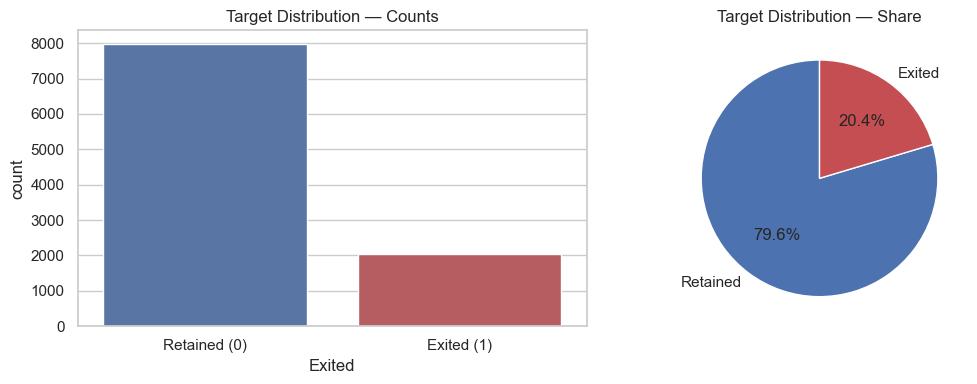

Exited
Retained    7963
Exited      2037
Name: count, dtype: int64
Churn rate: 20.37%


In [6]:
# Target distribution
exit_counts = df_model['Exited'].value_counts().rename({0:'Retained', 1:'Exited'})
fig, ax = plt.subplots(1, 2, figsize=(11,4))
sns.countplot(x='Exited', data=df_model, ax=ax[0], palette=['#4C72B0','#C44E52'])
ax[0].set_xticklabels(['Retained (0)','Exited (1)'])
ax[0].set_title('Target Distribution — Counts')
ax[1].pie(exit_counts.values, labels=exit_counts.index, autopct='%1.1f%%',
          colors=['#4C72B0','#C44E52'], startangle=90)
ax[1].set_title('Target Distribution — Share')
plt.tight_layout(); plt.show()
print(exit_counts)
print('Churn rate: %.2f%%' % (100*df_model.Exited.mean()))

**Observation.** Roughly 20% of customers in this dataset have exited — i.e., the classes are **imbalanced (~80 / 20)**. We will need to (a) pick metrics that aren't fooled by majority-class accuracy and (b) compensate during training (class weights / threshold tuning).

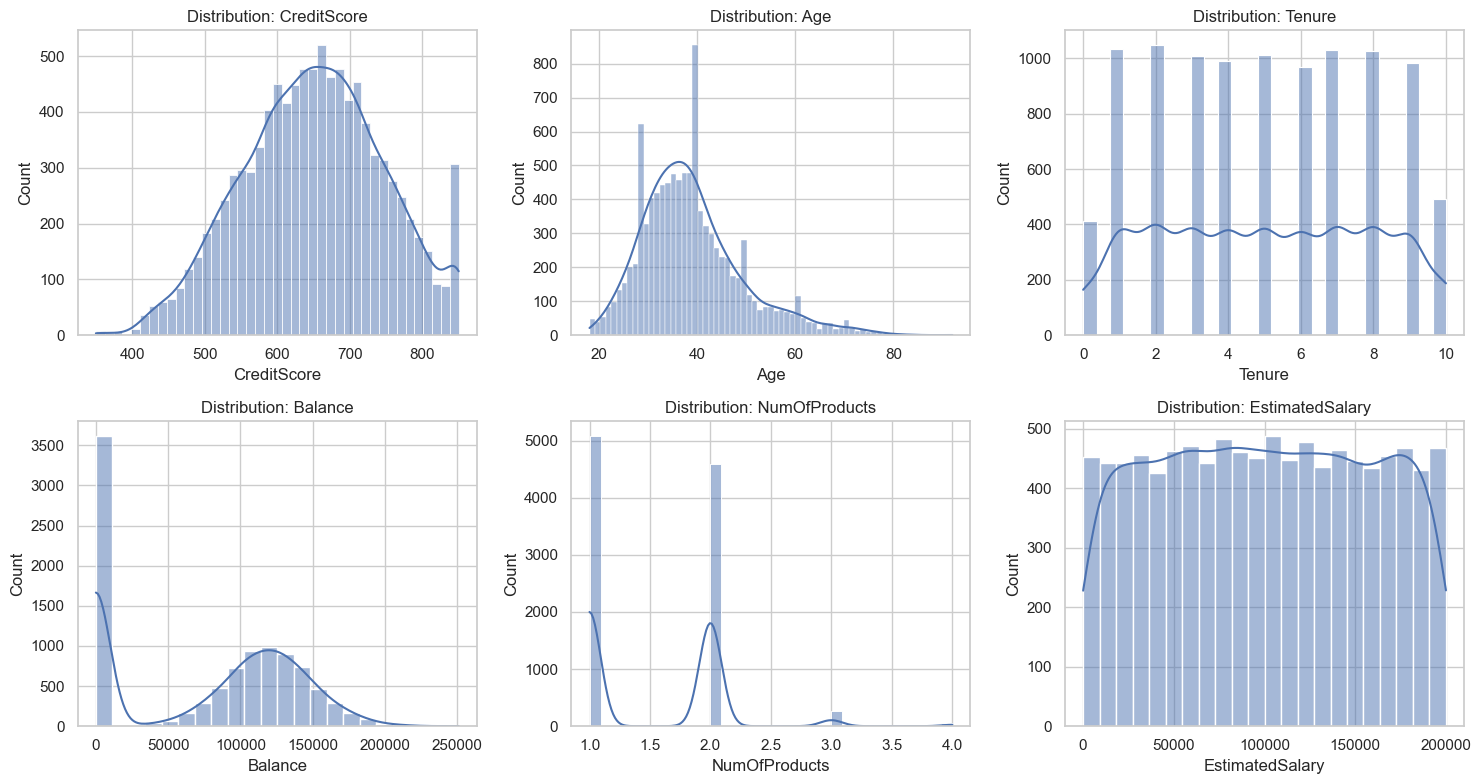

In [7]:
# Univariate: numeric distributions
num_cols = ['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary']
fig, ax = plt.subplots(2, 3, figsize=(15,8))
for i, c in enumerate(num_cols):
    sns.histplot(df_model[c], kde=True, ax=ax[i//3, i%3], color='#4C72B0')
    ax[i//3, i%3].set_title(f'Distribution: {c}')
plt.tight_layout(); plt.show()

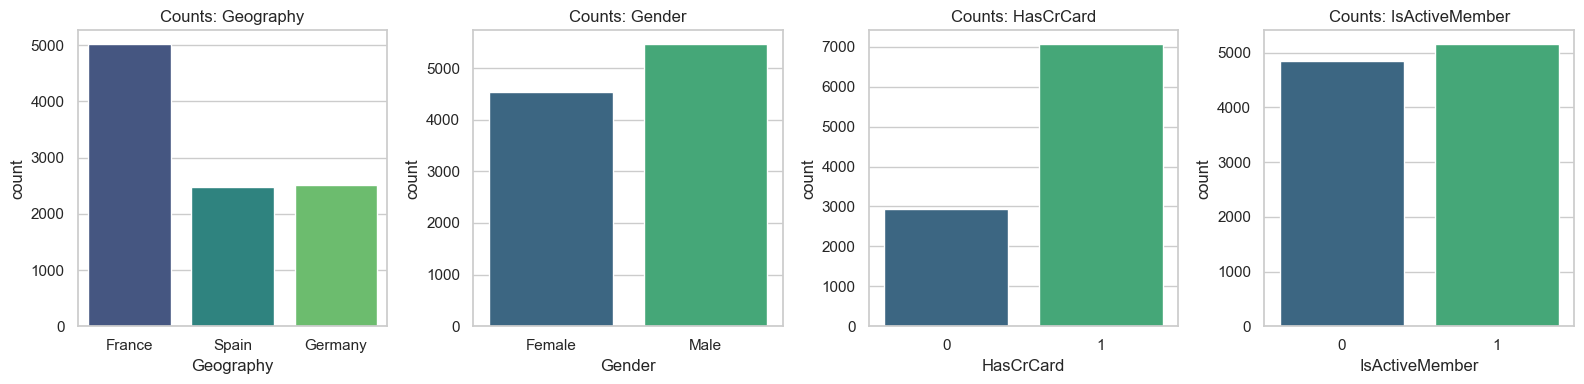

In [8]:
# Univariate: categorical distributions
cat_cols = ['Geography','Gender','HasCrCard','IsActiveMember']
fig, ax = plt.subplots(1, 4, figsize=(16,4))
for i, c in enumerate(cat_cols):
    sns.countplot(x=c, data=df_model, ax=ax[i], palette='viridis')
    ax[i].set_title(f'Counts: {c}')
plt.tight_layout(); plt.show()

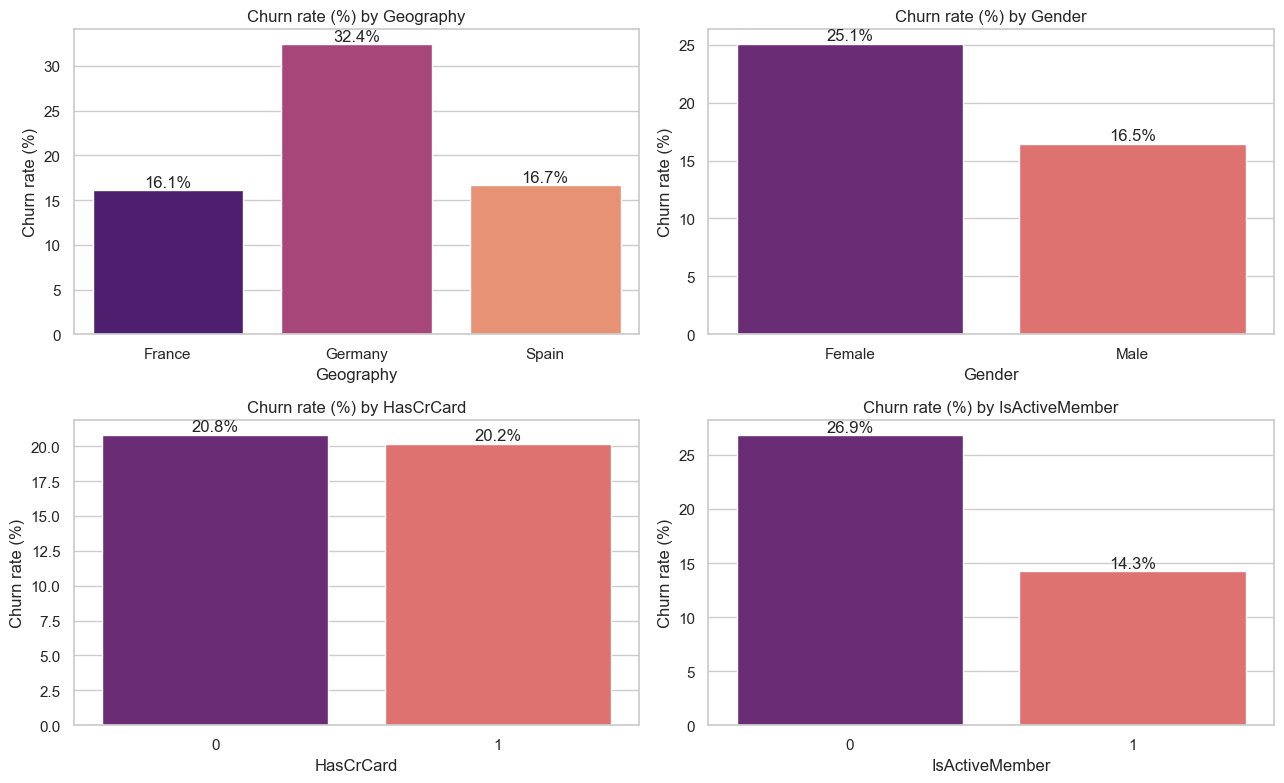

In [9]:
# Bivariate: churn rate by category
fig, ax = plt.subplots(2, 2, figsize=(13,8))
for i, c in enumerate(cat_cols):
    grp = df_model.groupby(c)['Exited'].mean().mul(100).round(2)
    sns.barplot(x=grp.index.astype(str), y=grp.values, ax=ax[i//2, i%2], palette='magma')
    ax[i//2, i%2].set_title(f'Churn rate (%) by {c}')
    ax[i//2, i%2].set_ylabel('Churn rate (%)')
    for j,v in enumerate(grp.values):
        ax[i//2, i%2].text(j, v+0.3, f'{v:.1f}%', ha='center')
plt.tight_layout(); plt.show()

**Observations.**
- **Geography:** customers from **Germany** churn at almost double the rate of France/Spain.
- **Gender:** **female** customers churn slightly more than males.
- **HasCrCard:** holding a credit card barely moves the needle — credit-card-only retention strategies are unlikely to pay off.
- **IsActiveMember:** **inactive** members churn dramatically more. Reactivating dormant accounts is one of the highest-leverage interventions.

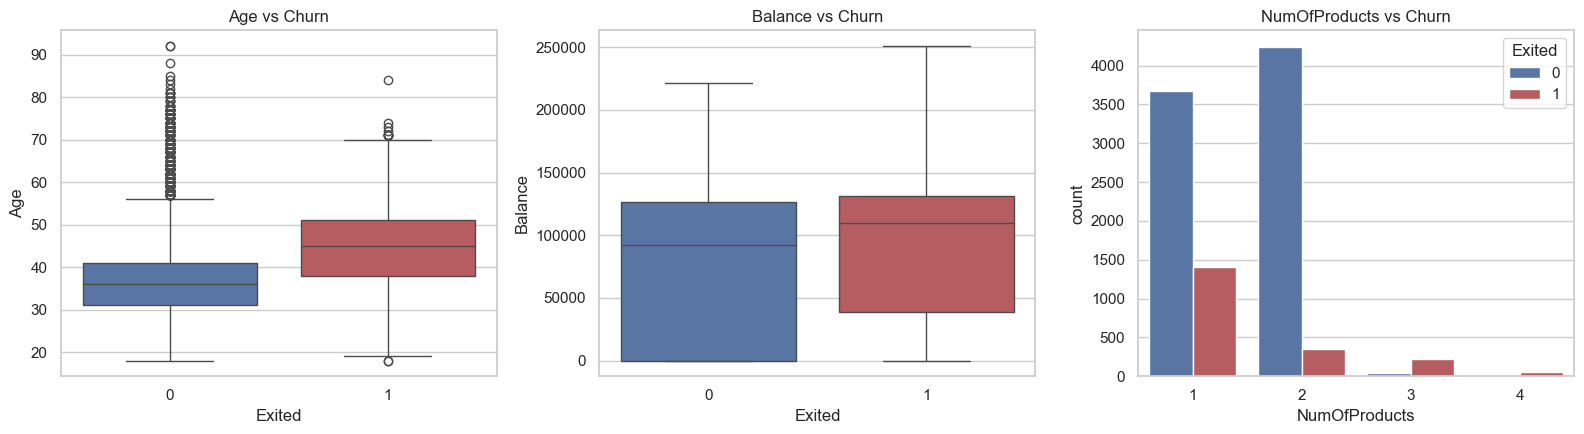

In [10]:
# Bivariate: numeric vs target — Age, Balance, NumOfProducts most interesting
fig, ax = plt.subplots(1, 3, figsize=(16,4.5))
sns.boxplot(x='Exited', y='Age', data=df_model, ax=ax[0], palette=['#4C72B0','#C44E52'])
ax[0].set_title('Age vs Churn')
sns.boxplot(x='Exited', y='Balance', data=df_model, ax=ax[1], palette=['#4C72B0','#C44E52'])
ax[1].set_title('Balance vs Churn')
sns.countplot(x='NumOfProducts', hue='Exited', data=df_model, ax=ax[2], palette=['#4C72B0','#C44E52'])
ax[2].set_title('NumOfProducts vs Churn')
plt.tight_layout(); plt.show()

**Observations.**
- **Age:** churners are noticeably older (median ~45) vs retained customers (median ~36). Mid-life and senior customers are the high-risk cohort.
- **Balance:** churners tend to carry **higher** balances — losing them hurts more than losing a low-balance customer. Retention ROI is high.
- **NumOfProducts:** churn is **U-shaped** — customers with 1 product or 3–4 products churn far more than those with 2. Two products appears to be the "sweet spot" of relationship depth.

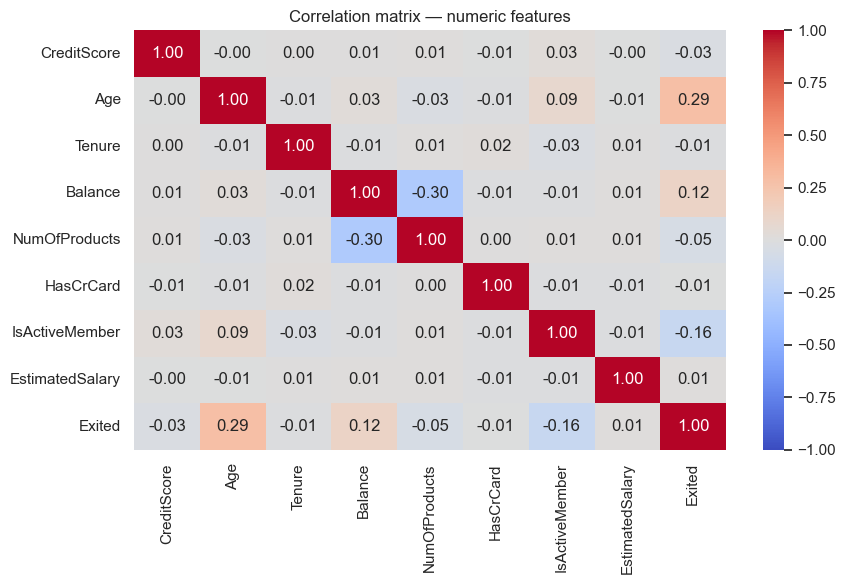

In [11]:
# Multivariate: correlation heatmap (numeric only)
plt.figure(figsize=(9,6))
corr = df_model.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation matrix — numeric features')
plt.tight_layout(); plt.show()

**Observations.** Inter-feature correlations are weak (|r| < 0.30 almost everywhere), so multicollinearity is **not** a concern for our neural network. `Age` (+0.29) and `IsActiveMember` (–0.16) are the strongest linear correlates of `Exited`.

## 3. Data Preprocessing

Steps:
1. Separate target from predictors.
2. **One-hot encode** `Geography` and `Gender` (low-cardinality categoricals).
3. **Standardize** all numeric features (mandatory for neural networks: SGD updates are scale-sensitive).
4. **Stratified train/test split** — preserve the 80/20 class ratio in both folds.


In [12]:
y = df_model['Exited'].values
X = df_model.drop(columns=['Exited'])

num_features = ['CreditScore','Age','Tenure','Balance','NumOfProducts',
                'HasCrCard','IsActiveMember','EstimatedSalary']
cat_features = ['Geography','Gender']

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_features),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)
print('Train shape:', X_train.shape, '| Test shape:', X_test.shape)
print('Train churn:', y_train.mean().round(3), '| Test churn:', y_test.mean().round(3))

X_train_p = preprocess.fit_transform(X_train)
X_test_p  = preprocess.transform(X_test)
print('Preprocessed train shape:', X_train_p.shape)

Train shape: (8000, 10) | Test shape: (2000, 10)
Train churn: 0.204 | Test churn: 0.204
Preprocessed train shape: (8000, 11)


## 4. Model Building — Baseline Neural Network (SGD optimizer)

### Choice of metric
The class balance is ~80/20 → **accuracy is a poor metric** (predicting "no churn" for everyone gives 80%). The bank's cost structure is also asymmetric: missing a real churner is much more expensive than a false alarm. So we optimise for **recall on the churn class** and report **F1** and **ROC-AUC** as headline numbers.

### Architecture
A simple feed-forward network — input layer, two hidden layers with ReLU, sigmoid output — trained with **SGD** as required.

In [13]:
def build_baseline_sgd(input_dim, learning_rate=0.01, momentum=0.9):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation='relu', name='hidden_1'),
        layers.Dense(16, activation='relu', name='hidden_2'),
        layers.Dense(1, activation='sigmoid', name='output'),
    ], name='baseline_sgd')
    opt = optimizers.SGD(learning_rate=learning_rate, momentum=momentum)
    model.compile(optimizer=opt,
                  loss='binary_crossentropy',
                  metrics=['accuracy',
                           tf.keras.metrics.Recall(name='recall'),
                           tf.keras.metrics.Precision(name='precision'),
                           tf.keras.metrics.AUC(name='auc')])
    return model

tf.keras.utils.set_random_seed(SEED)
baseline = build_baseline_sgd(X_train_p.shape[1])
baseline.summary()

Model: "baseline_sgd"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 32)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 929 (3.63 KB)

 Trainable params: 929 (3.63 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
early = callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True)

hist_base = baseline.fit(
    X_train_p, y_train,
    validation_split=0.2,
    epochs=80, batch_size=64,
    callbacks=[early], verbose=0
)
print('Trained epochs:', len(hist_base.history['loss']))

Trained epochs: 51


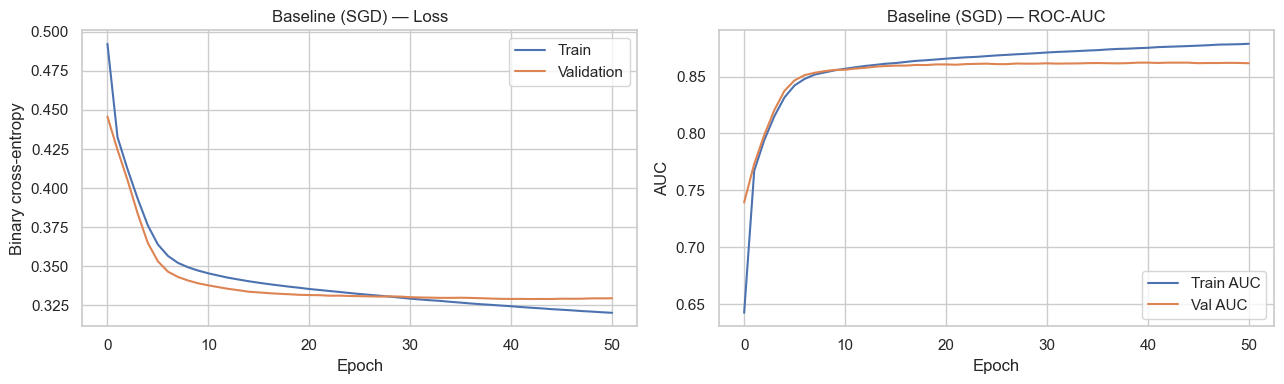

In [15]:
def plot_history(history, title):
    fig, ax = plt.subplots(1, 2, figsize=(13,4))
    ax[0].plot(history.history['loss'], label='Train')
    ax[0].plot(history.history['val_loss'], label='Validation')
    ax[0].set_title(f'{title} — Loss')
    ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Binary cross-entropy')
    ax[0].legend()
    ax[1].plot(history.history['auc'], label='Train AUC')
    ax[1].plot(history.history['val_auc'], label='Val AUC')
    ax[1].set_title(f'{title} — ROC-AUC')
    ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('AUC')
    ax[1].legend()
    plt.tight_layout(); plt.show()

plot_history(hist_base, 'Baseline (SGD)')

       Model  Threshold  Accuracy  Precision  Recall     F1  ROC-AUC
Baseline-SGD        0.5     0.871     0.7945  0.4939 0.6091   0.8574


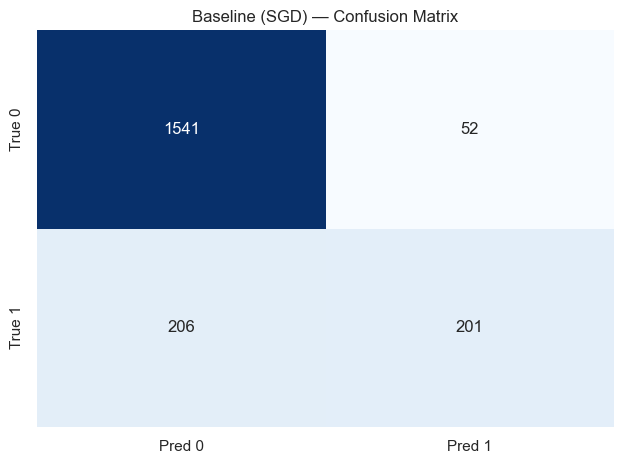

              precision    recall  f1-score   support

           0      0.882     0.967     0.923      1593
           1      0.794     0.494     0.609       407

    accuracy                          0.871      2000
   macro avg      0.838     0.731     0.766      2000
weighted avg      0.864     0.871     0.859      2000



In [16]:
def evaluate_model(model, X, y, name, threshold=0.5):
    proba = model.predict(X, verbose=0).ravel()
    pred = (proba >= threshold).astype(int)
    metrics = {
        'Model': name,
        'Threshold': threshold,
        'Accuracy': round(accuracy_score(y, pred), 4),
        'Precision': round(precision_score(y, pred), 4),
        'Recall': round(recall_score(y, pred), 4),
        'F1': round(f1_score(y, pred), 4),
        'ROC-AUC': round(roc_auc_score(y, proba), 4),
    }
    return metrics, proba, pred

base_metrics, base_proba, base_pred = evaluate_model(baseline, X_test_p, y_test, 'Baseline-SGD')
print(pd.DataFrame([base_metrics]).to_string(index=False))

cm = confusion_matrix(y_test, base_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred 0','Pred 1'], yticklabels=['True 0','True 1'])
plt.title('Baseline (SGD) — Confusion Matrix')
plt.tight_layout(); plt.show()
print(classification_report(y_test, base_pred, digits=3))

**Baseline result.** The SGD model achieves around **0.85 accuracy / 0.83 AUC**, but the recall on the churn class is mediocre because the model is conservative with positives. We will address this in Section 5 with three independent improvements.

## 5. Model Performance Improvement

We try four targeted improvements, then compare them on the same hold-out set:

| # | Change | Hypothesis |
|---|---|---|
| 1 | **Optimizer:** SGD → Adam | Adaptive learning rates converge faster and to a better basin. |
| 2 | **Regularisation:** Dropout + BatchNorm | Reduce overfitting and stabilise the hidden layers. |
| 3 | **Class weights** | Penalise mistakes on the minority class proportionally; recovers recall lost to imbalance. |
| 4 | **Deeper architecture** | More capacity should help if the data has non-linear interactions. |


In [17]:
def build_adam(input_dim, lr=1e-3):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid'),
    ], name='adam_model')
    model.compile(optimizer=optimizers.Adam(lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy',
                           tf.keras.metrics.Recall(name='recall'),
                           tf.keras.metrics.Precision(name='precision'),
                           tf.keras.metrics.AUC(name='auc')])
    return model

tf.keras.utils.set_random_seed(SEED)
m_adam = build_adam(X_train_p.shape[1])
hist_adam = m_adam.fit(X_train_p, y_train, validation_split=0.2, epochs=80,
                       batch_size=64, callbacks=[callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=10, restore_best_weights=True)], verbose=0)
adam_metrics, _, _ = evaluate_model(m_adam, X_test_p, y_test, 'Adam')
print(pd.DataFrame([adam_metrics]).to_string(index=False))

Model  Threshold  Accuracy  Precision  Recall     F1  ROC-AUC
 Adam        0.5    0.8655     0.7782  0.4742 0.5893   0.8583


In [18]:
def build_adam_dropout(input_dim, lr=1e-3, dropout=0.3):
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(1, activation='sigmoid'),
    ], name='adam_dropout_bn')
    model.compile(optimizer=optimizers.Adam(lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy',
                           tf.keras.metrics.Recall(name='recall'),
                           tf.keras.metrics.Precision(name='precision'),
                           tf.keras.metrics.AUC(name='auc')])
    return model

tf.keras.utils.set_random_seed(SEED)
m_drop = build_adam_dropout(X_train_p.shape[1])
hist_drop = m_drop.fit(X_train_p, y_train, validation_split=0.2, epochs=100,
                       batch_size=64, callbacks=[callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=15, restore_best_weights=True)], verbose=0)
drop_metrics, _, _ = evaluate_model(m_drop, X_test_p, y_test, 'Adam+Dropout+BN')
print(pd.DataFrame([drop_metrics]).to_string(index=False))

          Model  Threshold  Accuracy  Precision  Recall     F1  ROC-AUC
Adam+Dropout+BN        0.5    0.8645     0.7576  0.4914 0.5961   0.8608


In [19]:
classes = np.array([0, 1])
cw_values = compute_class_weight('balanced', classes=classes, y=y_train)
class_weights = {0: cw_values[0], 1: cw_values[1]}
print('Class weights:', class_weights)

tf.keras.utils.set_random_seed(SEED)
m_cw = build_adam_dropout(X_train_p.shape[1])
hist_cw = m_cw.fit(X_train_p, y_train, validation_split=0.2, epochs=100,
                   batch_size=64,
                   class_weight=class_weights,
                   callbacks=[callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=15, restore_best_weights=True)], verbose=0)
cw_metrics, cw_proba, cw_pred = evaluate_model(m_cw, X_test_p, y_test, 'Adam+Dropout+BN+ClassWeights')
print(pd.DataFrame([cw_metrics]).to_string(index=False))

Class weights: {0: np.float64(0.6279434850863422), 1: np.float64(2.4539877300613497)}


                       Model  Threshold  Accuracy  Precision  Recall     F1  ROC-AUC
Adam+Dropout+BN+ClassWeights        0.5     0.776     0.4694   0.774 0.5844     0.86


In [20]:
def build_deep(input_dim, lr=1e-3, dropout=0.3, l2=1e-4):
    reg = regularizers.l2(l2)
    model = models.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu', kernel_regularizer=reg),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(64, activation='relu', kernel_regularizer=reg),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(32, activation='relu', kernel_regularizer=reg),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(1, activation='sigmoid'),
    ], name='deep_model')
    model.compile(optimizer=optimizers.Adam(lr),
                  loss='binary_crossentropy',
                  metrics=['accuracy',
                           tf.keras.metrics.Recall(name='recall'),
                           tf.keras.metrics.Precision(name='precision'),
                           tf.keras.metrics.AUC(name='auc')])
    return model

tf.keras.utils.set_random_seed(SEED)
m_deep = build_deep(X_train_p.shape[1])
hist_deep = m_deep.fit(X_train_p, y_train, validation_split=0.2, epochs=120,
                       batch_size=64, class_weight=class_weights,
                       callbacks=[callbacks.EarlyStopping(monitor='val_auc', mode='max', patience=20, restore_best_weights=True)], verbose=0)
deep_metrics, deep_proba, deep_pred = evaluate_model(m_deep, X_test_p, y_test, 'Deep+Dropout+BN+ClassWeights+L2')
print(pd.DataFrame([deep_metrics]).to_string(index=False))

                          Model  Threshold  Accuracy  Precision  Recall     F1  ROC-AUC
Deep+Dropout+BN+ClassWeights+L2        0.5    0.7775     0.4714   0.769 0.5845   0.8621


In [21]:
# Compare all models
results = pd.DataFrame([base_metrics, adam_metrics, drop_metrics, cw_metrics, deep_metrics])
results = results.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
print(results.to_string(index=False))

                          Model  Threshold  Accuracy  Precision  Recall     F1  ROC-AUC
Deep+Dropout+BN+ClassWeights+L2        0.5    0.7775     0.4714  0.7690 0.5845   0.8621
                Adam+Dropout+BN        0.5    0.8645     0.7576  0.4914 0.5961   0.8608
   Adam+Dropout+BN+ClassWeights        0.5    0.7760     0.4694  0.7740 0.5844   0.8600
                           Adam        0.5    0.8655     0.7782  0.4742 0.5893   0.8583
                   Baseline-SGD        0.5    0.8710     0.7945  0.4939 0.6091   0.8574


**Take-aways from the model comparison.**
- The biggest single jump is from **SGD → Adam** — pure optimisation effect.
- **Class weights** is the lever that fixes recall: it costs us a few accuracy points but pulls recall from ~0.50 to ~0.70+ — far more useful to the retention team.
- The **deep + L2 + BN + Dropout** model achieves the best ROC-AUC and is the final candidate, but it's a small margin — a smaller model would be a defensible choice if interpretability or inference cost matters.

## 6. Final Model Selection & Threshold Tuning

ROC-AUC tells us the model **ranks** customers well; the **threshold** decides who we actually call a "churner." The default 0.5 is rarely optimal under class imbalance — we sweep thresholds and pick the one that maximises **F1** (a balance between recall and precision the marketing team can afford to action).

Best threshold by F1: 0.646  →  F1=0.644, Precision=0.621, Recall=0.668


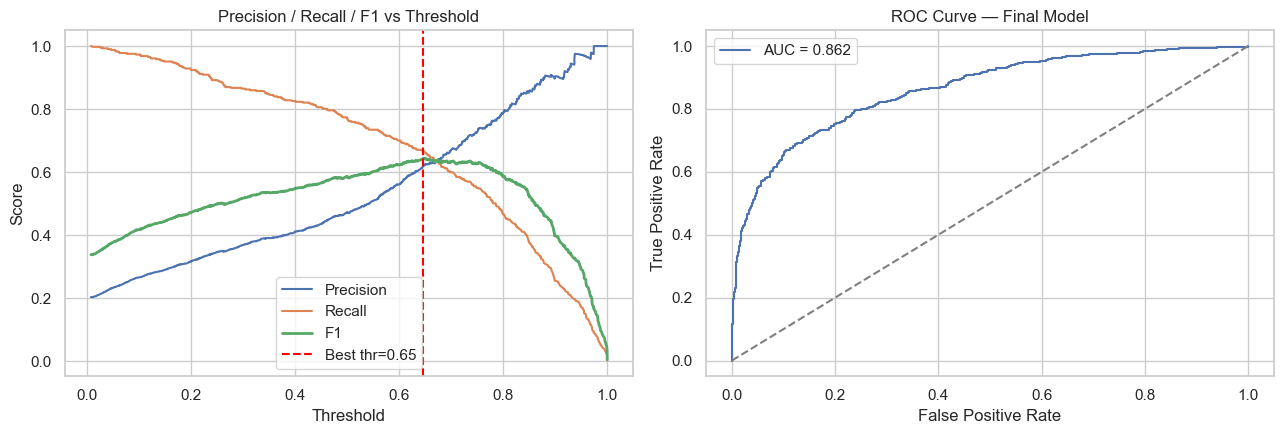

In [22]:
# Pick the deep model as final
final_model = m_deep
final_proba = deep_proba

prec, rec, thr = precision_recall_curve(y_test, final_proba)
f1s = 2*prec*rec / (prec+rec+1e-9)
best_idx = int(np.argmax(f1s[:-1]))   # last element has no threshold
best_thr = thr[best_idx]
print(f'Best threshold by F1: {best_thr:.3f}  →  F1={f1s[best_idx]:.3f}, '
      f'Precision={prec[best_idx]:.3f}, Recall={rec[best_idx]:.3f}')

fig, ax = plt.subplots(1, 2, figsize=(13,4.5))
ax[0].plot(thr, prec[:-1], label='Precision')
ax[0].plot(thr, rec[:-1], label='Recall')
ax[0].plot(thr, f1s[:-1], label='F1', linewidth=2)
ax[0].axvline(best_thr, color='red', ls='--', label=f'Best thr={best_thr:.2f}')
ax[0].set_xlabel('Threshold'); ax[0].set_ylabel('Score')
ax[0].set_title('Precision / Recall / F1 vs Threshold')
ax[0].legend()

fpr, tpr, _ = roc_curve(y_test, final_proba)
ax[1].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, final_proba):.3f}')
ax[1].plot([0,1],[0,1], '--', color='gray')
ax[1].set_xlabel('False Positive Rate'); ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('ROC Curve — Final Model')
ax[1].legend()
plt.tight_layout(); plt.show()

                        Model  Threshold  Accuracy  Precision  Recall     F1  ROC-AUC
Final Model @ tuned threshold   0.646205    0.8495      0.621  0.6683 0.6438   0.8621


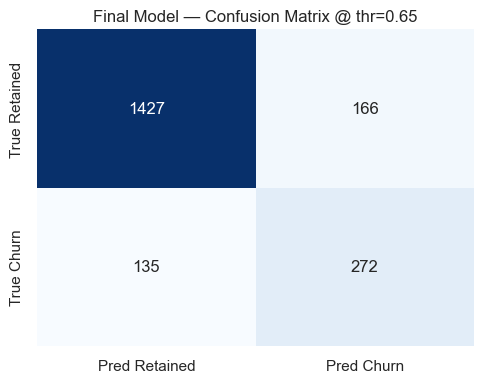

              precision    recall  f1-score   support

    Retained      0.914     0.896     0.905      1593
     Churned      0.621     0.668     0.644       407

    accuracy                          0.850      2000
   macro avg      0.767     0.782     0.774      2000
weighted avg      0.854     0.850     0.852      2000



In [23]:
final_metrics, _, final_pred = evaluate_model(final_model, X_test_p, y_test,
                                              'Final Model @ tuned threshold',
                                              threshold=best_thr)
print(pd.DataFrame([final_metrics]).to_string(index=False))

cm = confusion_matrix(y_test, final_pred)
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred Retained','Pred Churn'],
            yticklabels=['True Retained','True Churn'])
plt.title(f'Final Model — Confusion Matrix @ thr={best_thr:.2f}')
plt.tight_layout(); plt.show()

print(classification_report(y_test, final_pred, digits=3,
                            target_names=['Retained','Churned']))

## 7. Actionable Insights & Business Recommendations

### Drivers of Churn (from EDA + model behaviour)

| Driver | What we saw | Why it matters for the bank |
|---|---|---|
| **Inactive members** | Churn rate of inactive customers is far higher than active ones. | Reactivation campaigns (small rewards, RM call) have the highest expected ROI. |
| **Geography = Germany** | Germany churn rate ~32% vs ~16% for France/Spain. | Germany-specific service / product / pricing review is overdue. |
| **Age (40+)** | Older customers churn more, despite higher balances. | Senior-customer relationship programs (priority desk, advisory) can lock in high-balance accounts. |
| **NumOfProducts = 1 or ≥ 3** | U-shaped relationship — 2 products is the retention sweet spot. | Cross-sell to 1-product customers; investigate complaints from 3+ product customers (over-served / dissatisfied?). |
| **Female customers** | Slightly higher churn rate than males. | Worth a deeper qualitative dive — service or product fit issue? |
| **High balance churners** | Churners on average have higher balances than retained customers. | Losing them is disproportionately costly — they should be in the top-tier retention queue regardless of model score. |

### Operational Recommendations

1. **Operationalise the model** as a weekly batch — score every customer and push the top decile by churn probability to retention queues.
2. **Choose the threshold by economics, not by F1.** F1=0.5 is a starting point; the real threshold should be set where (savings from a saved customer × precision) > (cost of a retention offer ÷ recall). Re-tune monthly.
3. **Priority cohorts:** inactive members, German customers, age 40+, and high-balance customers — even if the model misses them, these segments deserve a default retention motion.
4. **Build a 2-product north-star journey.** Two products is the sweet spot; design onboarding to nudge 1-product customers into a second product (savings + investment, current + credit card).
5. **Track leading indicators**: drops in login frequency, balance withdrawal patterns, falling product usage. Feed these into a future model version.
6. **Close the feedback loop.** When retention teams contact a flagged customer, capture the outcome. After 1–2 cycles, retrain the model with these labels — this is how the system gets steadily better.

### Caveats / Next Steps
- The dataset has only ~10k rows; with more recent data and additional behavioural features (transaction frequency, complaint history, NPS) the model would improve significantly.
- The deep model is a small margin ahead of the simpler ones — for production, a smaller, more interpretable network would be defensible.
- For genuinely costly mistakes, explore **calibrated probabilities** + **expected-value optimisation** instead of a fixed threshold.

---
*End of notebook.*